In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/prices.csv")
demand = pd.read_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/demand.csv")
transport = pd.read_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/transport.csv")
supply = pd.read_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/supply.csv")

# Convert dates
prices["date"] = pd.to_datetime(prices["date"])
demand["date"] = pd.to_datetime(demand["date"])

In [3]:
price_series = prices.sort_values("date")

grouped_series = price_series.groupby(["crop", "market"])

#### Maize -> Lagos Series

In [6]:
maize_lagos = price_series[
    (price_series["crop"] == "maize") &
    (price_series["market"] == "lagos")
]

maize_lagos = maize_lagos.set_index("date")

print(maize_lagos.shape)
maize_lagos.head()

(731, 3)


,crop,market,price
date,,,
2023-01-01,maize,lagos,272.61
2023-01-02,maize,lagos,269.46
2023-01-03,maize,lagos,249.00
2023-01-04,maize,lagos,262.24
2023-01-05,maize,lagos,291.20


##### Forecast

In [8]:
from statsmodels.tsa.arima.model import ARIMA

series = maize_lagos["price"]

model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

print(forecast)

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2025-01-01    341.137327
2025-01-02    341.161319
2025-01-03    341.160970
2025-01-04    341.160975
2025-01-05    341.160975
2025-01-06    341.160975
2025-01-07    341.160975
2025-01-08    341.160975
2025-01-09    341.160975
2025-01-10    341.160975
2025-01-11    341.160975
2025-01-12    341.160975
Freq: D, Name: predicted_mean, dtype: float64


In [23]:
forecast.to_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/price_forecast.csv", index= False)

##### Demand Forecast

In [10]:
demand_series = demand[
    (demand["crop"] == "maize") &
    (demand["market"] == "lagos")
]

demand_series = demand_series.set_index("date")

model = ARIMA(demand_series["demand"], order=(1,1,1))
model_fit = model.fit()

demand_forecast = model_fit.forecast(steps=12)

print(demand_forecast)

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2023-03-26    8091.432925
2023-03-27    8070.060380
2023-03-28    8065.852974
2023-03-29    8065.024703
2023-03-30    8064.861649
2023-03-31    8064.829551
2023-04-01    8064.823232
2023-04-02    8064.821988
2023-04-03    8064.821743
2023-04-04    8064.821695
2023-04-05    8064.821685
2023-04-06    8064.821683
Freq: D, Name: predicted_mean, dtype: float64


In [24]:
demand_forecast.to_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/demand_forecast.csv", index= False)

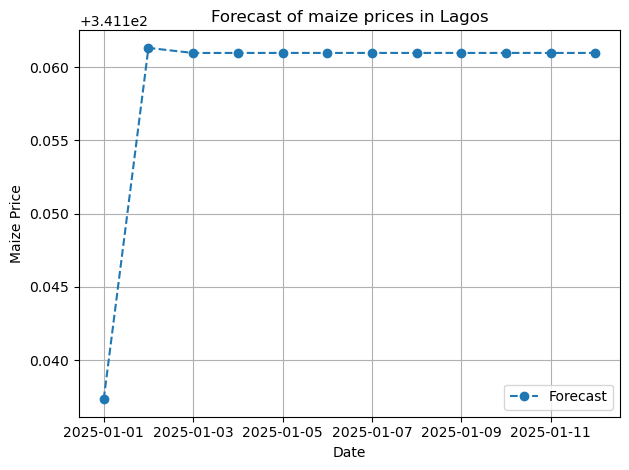

In [15]:
plt.plot(forecast, label='Forecast', linestyle='--', marker='o')
plt.title("Forecast of maize prices in Lagos")
plt.xlabel("Date")
plt.ylabel("Maize Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

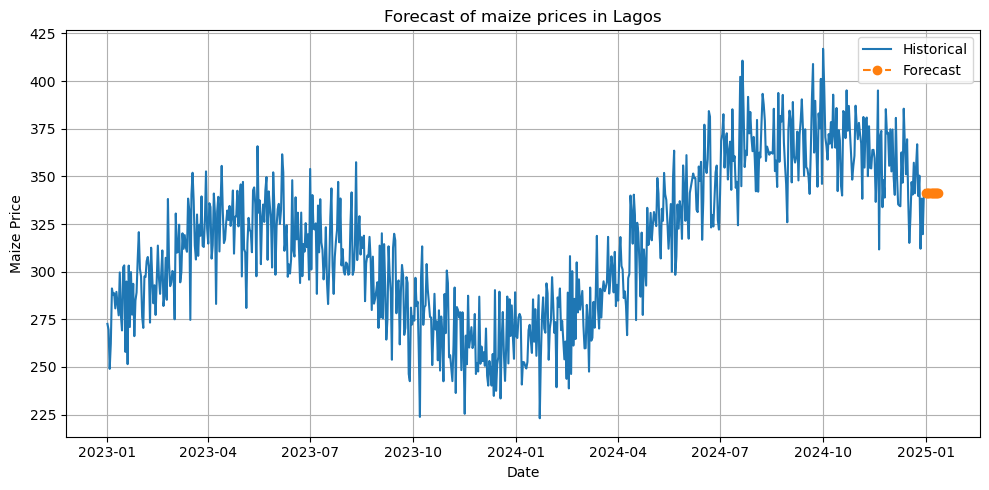

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(series, label='Historical')
plt.plot(forecast, label='Forecast', linestyle='--', marker='o')
plt.title("Forecast of maize prices in Lagos")
plt.xlabel("Date")
plt.ylabel("Maize Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [20]:
demand.head(), demand.tail()

(        date   crop  market  demand
 0 2023-01-01  maize   abuja    8334
 1 2023-01-01  maize  ibadan   10364
 2 2023-01-01  maize   lagos    8348
 3 2023-01-01  maize   minna    7392
 4 2023-01-01   rice   abuja    7234,
           date    crop  market  demand
 995 2023-03-24  tomato   minna    4146
 996 2023-03-25   maize   abuja    8970
 997 2023-03-25   maize  ibadan    6728
 998 2023-03-25   maize   lagos    8200
 999 2023-03-25   maize   minna    7264)

In [19]:
demand_series.shape

(84, 3)

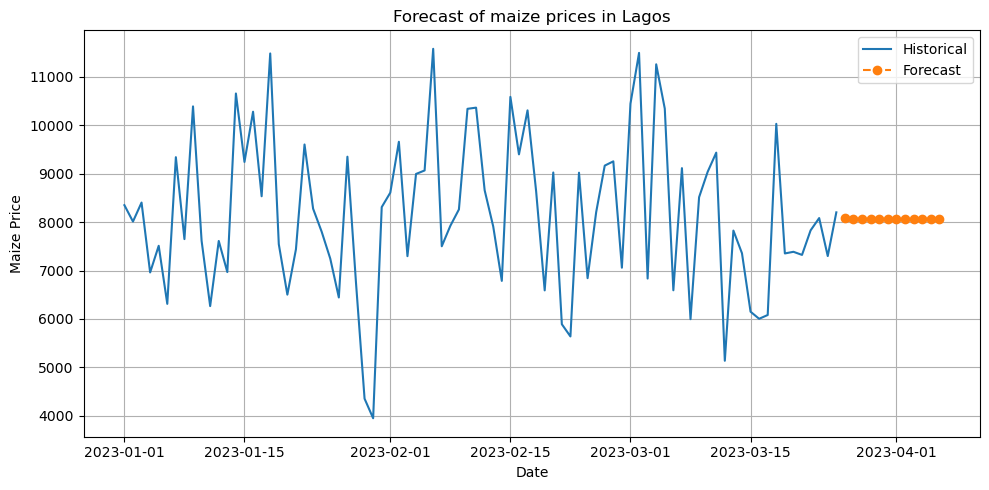

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(demand_series["demand"], label='Historical')
plt.plot(demand_forecast, label='Forecast', linestyle='--', marker='o')
plt.title("Forecast of maize prices in Lagos")
plt.xlabel("Date")
plt.ylabel("Maize Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [21]:
import numpy as np

forecast_mean = forecast.mean()
forecast_std = forecast.std()

forecast_parameters = {
    "expected_price": forecast_mean,
    "price_volatility": forecast_std,
    "p10_price": np.percentile(forecast, 10),
    "p90_price": np.percentile(forecast, 90)
}

print(forecast_parameters)

{'expected_price': np.float64(341.1590328305597), 'price_volatility': 0.006836185336319809, 'p10_price': np.float64(341.1609708141758), 'p90_price': np.float64(341.16097536447523)}


In [22]:
parameters = pd.DataFrame({
    "crop": ["maize"],
    "market": ["lagos"],
    "expected_price": [forecast_mean],
    "volatility": [forecast_std]
})

parameters.to_csv("C:/Users/USER/Projects/Produce_Aggregation_and_Distribution_Decision_System/data/processed/optimization_parameters.csv", index=False)

parameters

,crop,market,expected_price,volatility
0,maize,lagos,341.159033,0.006836
